<a href="https://colab.research.google.com/github/springboardmentor443m-coder/AI-Skin-Intelligence-Personalized-Skincare-Planner/blob/Subhransu-Sekhar/Skin_care_Product_Recommendation1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
# Main dataset
# Simple upload
uploaded = files.upload()

# Load the csv
raw_df = pd.read_csv('product_info.csv')
print(f"Dataset loaded successfully. Shape: {raw_df.shape}")
display(raw_df.head())

Saving product_info.csv to product_info.csv
Dataset loaded successfully. Shape: (8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


# Skincare Data Extraction and Cleaning Pipeline
This step isolates skincare products, extracts relevant metadata, parses skin-specific tags from highlights, and cleans the text for the recommendation engine.

In [ ]:
# import pandas as pd
# import ast
# from collections import Counter
# # ( for old  refined data set 2 )
# # 1. Discover all unique tags in 'highlights' to find missing types/concerns
# all_tags = []
# for h in raw_df[raw_df['primary_category'] == 'Skincare']['highlights'].dropna():
#     try:
#         all_tags.extend(ast.literal_eval(h))
#     except:
#         continue

# unique_tags = sorted(list(set([t.lower() for t in all_tags])))
# print(f"Total unique tags discovered: {len(unique_tags)}")
# print("Sample tags found:", unique_tags[:20])

# # Grouping logic based on discovery (expanding on previous lists)
# # We'll use these to build more accurate columns in the next cell
# skin_type_keywords = ['oily', 'dry', 'normal', 'combination', 'sensitive', 'mature']
# skin_concern_keywords = [
#     'acne', 'aging', 'dark spots', 'pores', 'redness', 'fine lines', 'wrinkles',
#     'dullness', 'uneven texture', 'dark circles', 'puffiness', 'loss of firmness',
#     'hyperpigmentation', 'eczema', 'sun damage'
# ]

Total unique tags discovered: 85
Sample tags found: ['aha/glycolic acid', 'alcohol free', 'all hair types', 'allure 2017 best of beauty award winner', 'allure 2018 best of beauty award winner', 'allure 2019 best of beauty award winner', 'allure 2020 best of beauty award winner', 'allure 2021 best of beauty award winner', 'allure 2021: clean beauty winner', 'allure 2022 best of beauty award winner', 'best for combination skin', 'best for dry skin', 'best for dry, combo, normal skin', 'best for normal skin', 'best for oily skin', 'best for oily, combo, normal skin', 'black owned at sephora', 'cbd', 'clean + planet positive', 'clean at sephora']


In [ ]:
import re
import ast
import pandas as pd
from google.colab import files

# Re-loading raw_df to fix NameError
try:
    raw_df = pd.read_csv('product_info.csv')
except FileNotFoundError:
    print("Please upload the product_info.csv file first.")
    uploaded = files.upload()
    raw_df = pd.read_csv('product_info.csv')

def final_precision_parser(highlight_str):
    if not highlight_str or pd.isna(highlight_str) or highlight_str == '':
        return "Universal", "General Care"
    try:
        tags = ast.literal_eval(highlight_str) if isinstance(highlight_str, str) else highlight_str
        tags = [str(t).lower().strip() for t in tags]
    except:
        return "Universal", "General Care"

    found_types = set()
    found_concerns = set()

    type_keywords = {'oily': 'Oily', 'dry': 'Dry', 'normal': 'Normal', 'combination': 'Combination', 'combo': 'Combination'}

    greedy_map = {
        'acne': 'Acne/Blemishes', 'blemish': 'Acne/Blemishes', 'breakout': 'Acne/Blemishes',
        'loss of firmness': 'Firmness/Elasticity', 'firmness': 'Firmness/Elasticity', 'elasticity': 'Firmness/Elasticity',
        'collagen': 'Collagen/Plumping', 'plumping': 'Collagen/Plumping', 'hyaluronic': 'Hydration',
        'fine lines': 'Fine Lines/Wrinkles', 'wrinkles': 'Fine Lines/Wrinkles',
        'anti-aging': 'Anti-Aging', 'aging': 'Anti-Aging', 'rejuvenating': 'Anti-Aging',
        'dark spots': 'Dark Spots', 'hyperpigmentation': 'Dark Spots', 'brightening': 'Brightening',
        'pores': 'Pores', 'blackheads': 'Pores',
        'redness': 'Redness', 'soothing': 'Redness', 'irritation': 'Redness', 'inflammation': 'Redness',
        'dullness': 'Dullness/Texture', 'uneven texture': 'Dullness/Texture', 'texture': 'Dullness/Texture',
        'dryness': 'Hydration/Dryness', 'hydrating': 'Hydration/Dryness', 'dehydration': 'Hydration/Dryness',
        'hypoallergenic': 'Hypoallergenic', 'sensitive': 'Sensitivity', 'eczema': 'Eczema',
        'spf': 'Sun Protection', 'uv protection': 'Sun Protection', 'vitamin c': 'Brightening/Vitamin C',
        'dark circles': 'Dark Circles', 'puffiness': 'Puffiness', 'under-eye': 'Eye Care'
    }

    for tag in tags:
        if 'best for' in tag:
            for k, v in type_keywords.items():
                if k in tag: found_types.add(v)

        for k, v in greedy_map.items():
            if k in tag:
                found_concerns.add(v)

    res_type = ", ".join(sorted(found_types)) if found_types else "Universal"
    res_concern = ", ".join(sorted(found_concerns)) if found_concerns else "General Care"
    return res_type, res_concern

# --- Pipeline Execution v12 (Corrected Cleaning) ---
skincare_v12 = raw_df[raw_df['primary_category'] == 'Skincare'].copy()
skincare_v12 = skincare_v12.dropna(subset=['ingredients']).reset_index(drop=True)

for col in ['highlights', 'ingredients', 'secondary_category', 'tertiary_category', 'brand_name', 'product_name']:
    skincare_v12[col] = skincare_v12[col].fillna('')

skincare_v12[['skin_types', 'skin_concerns']] = skincare_v12['highlights'].apply(lambda x: pd.Series(final_precision_parser(x)))

def final_clean_ingredients(text):
    text = str(text).lower()
    # Normalize slashes
    text = text.replace('\\', '/').replace('//', '/')
    while '//' in text: text = text.replace('//', '/')
    # Remove brackets, trademarks, and line breaks
    text = re.sub(r"[\[\]\*™®©\r\n]", " ", text)
    # Remove various quote styles
    text = re.sub(r"['\"\‘\’\“\”]", "", text)
    return re.sub(r"\s+", " ", text).strip()

skincare_v12['ingredients_cleaned'] = skincare_v12['ingredients'].apply(final_clean_ingredients)
skincare_v12['product_type'] = (skincare_v12['secondary_category'] + ' ' + skincare_v12['tertiary_category']).str.strip()
skincare_v12['price'] = skincare_v12['price_usd'].fillna(skincare_v12.get('child_min_price', 0)).astype(float)

for col in ['loves_count', 'rating', 'reviews']:
    skincare_v12[col] = pd.to_numeric(skincare_v12[col], errors='coerce').fillna(0)
    mx, mn = skincare_v12[col].max(), skincare_v12[col].min()
    skincare_v12[f'{col}_norm'] = (skincare_v12[col] - mn) / (mx - mn) if mx > mn else 0

final_cols = ['product_id', 'brand_name', 'product_name', 'price', 'product_type', 'loves_count_norm', 'rating_norm', 'reviews_norm', 'skin_types', 'skin_concerns', 'ingredients_cleaned']
output_v12 = 'final_skincare_v12_complete.csv'
skincare_v12[final_cols].to_csv(output_v12, index=False)

print(f"Corrected Pipeline v12 complete. Total: {len(skincare_v12)} products.")
display(skincare_v12[final_cols].head(5))
files.download(output_v12)

Corrected Pipeline v12 complete. Total: 2286 products.


,product_id,brand_name,product_name,price,product_type,loves_count_norm,rating_norm,reviews_norm,skin_types,skin_concerns,ingredients_cleaned
0,P439055,Algenist,GENIUS Sleeping Collagen Moisturizer,98.0,Moisturizers Moisturizers,0.031360,0.90826,0.081958,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), ethylhex..."
1,P421277,Algenist,GENIUS Liquid Collagen Serum,115.0,Treatments Face Serums,0.062766,0.80518,0.071907,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), propaned..."
2,P467602,Algenist,Triple Algae Eye Renewal Balm Eye Cream,68.0,Eye Care Eye Creams & Treatments,0.016545,0.90612,0.070852,Universal,General Care,"aqua (water/eau), stearic acid, isopropyl isos..."
3,P432045,Algenist,GENIUS Liquid Collagen Lip Treatment,29.0,Lip Balms & Treatments,0.041106,0.77442,0.040266,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), glycerin..."
4,P311143,Algenist,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,28.0,Sunscreen Face Sunscreen,0.025227,0.88268,0.031518,"Combination, Dry, Normal","Hypoallergenic, Sun Protection","octinoxate 7.5%, titanium dioxide 2%, zinc oxi..."


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EDA ANALYSIS

### 🛠️ Data Recovery: Upload Cleaned Dataset
If your session was restarted and you already have the cleaned CSV, run this cell to upload it so the EDA below can function.

In [5]:
from google.colab import files
import os

# Standard expected filename
expected_name = 'final_skincare_v12_complete.csv'
# Renamed version due to multiple uploads
renamed_name = 'final_skincare_v12_complete (1).csv'

if os.path.exists(renamed_name):
    os.replace(renamed_name, expected_name)
    print(f"\nSuccess: Renamed '{renamed_name}' to '{expected_name}'.")
    print("Dataset restored. You can now run the EDA cell below.")
elif os.path.exists(expected_name):
    print(f"\nSuccess: '{expected_name}' found. You can now run the EDA cell below.")
else:
    print("Please upload 'final_skincare_v12_complete.csv':")
    uploaded = files.upload()
    # Handle case where file is uploaded and renamed in one go
    for filename in uploaded.keys():
        if 'final_skincare_v12_complete' in filename:
            os.replace(filename, expected_name)
            print(f"\nSuccess: Dataset restored as {expected_name}.")


Success: Renamed 'final_skincare_v12_complete (1).csv' to 'final_skincare_v12_complete.csv'.
Dataset restored. You can now run the EDA cell below.


Dataset Shape: (2286, 11)
Missing Ingredients Count: 0


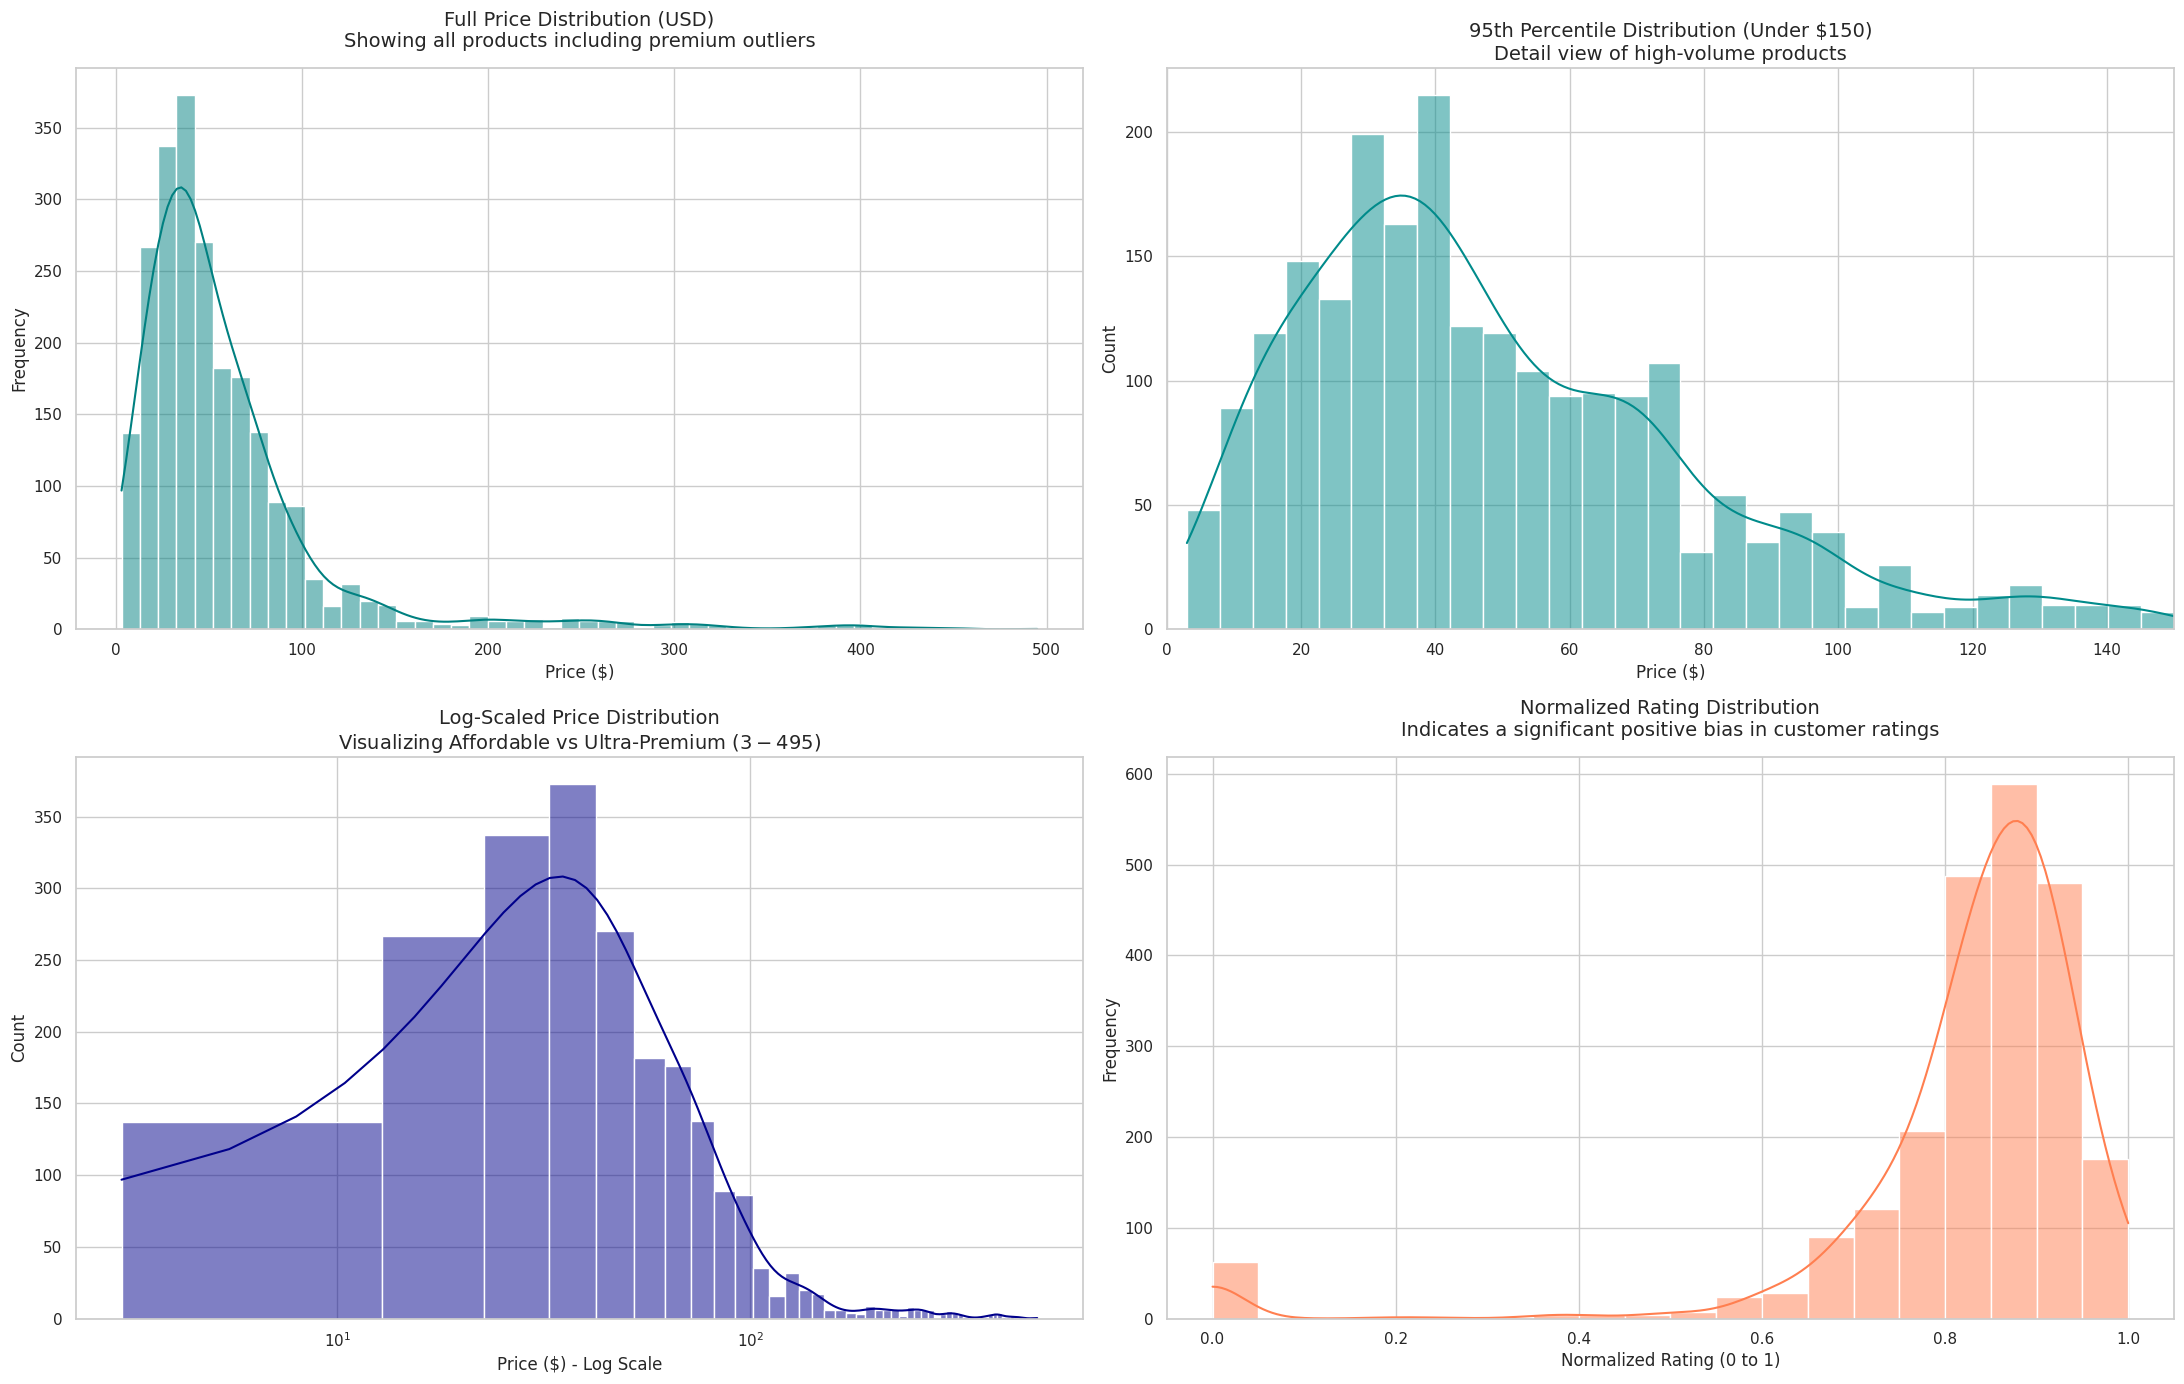

--- Price Analysis ---
The Log scale reveals the bi-modal peak around $44.0, while the 95th percentile clip eliminates the extreme tail (max $495.0) to focus on the core market density.


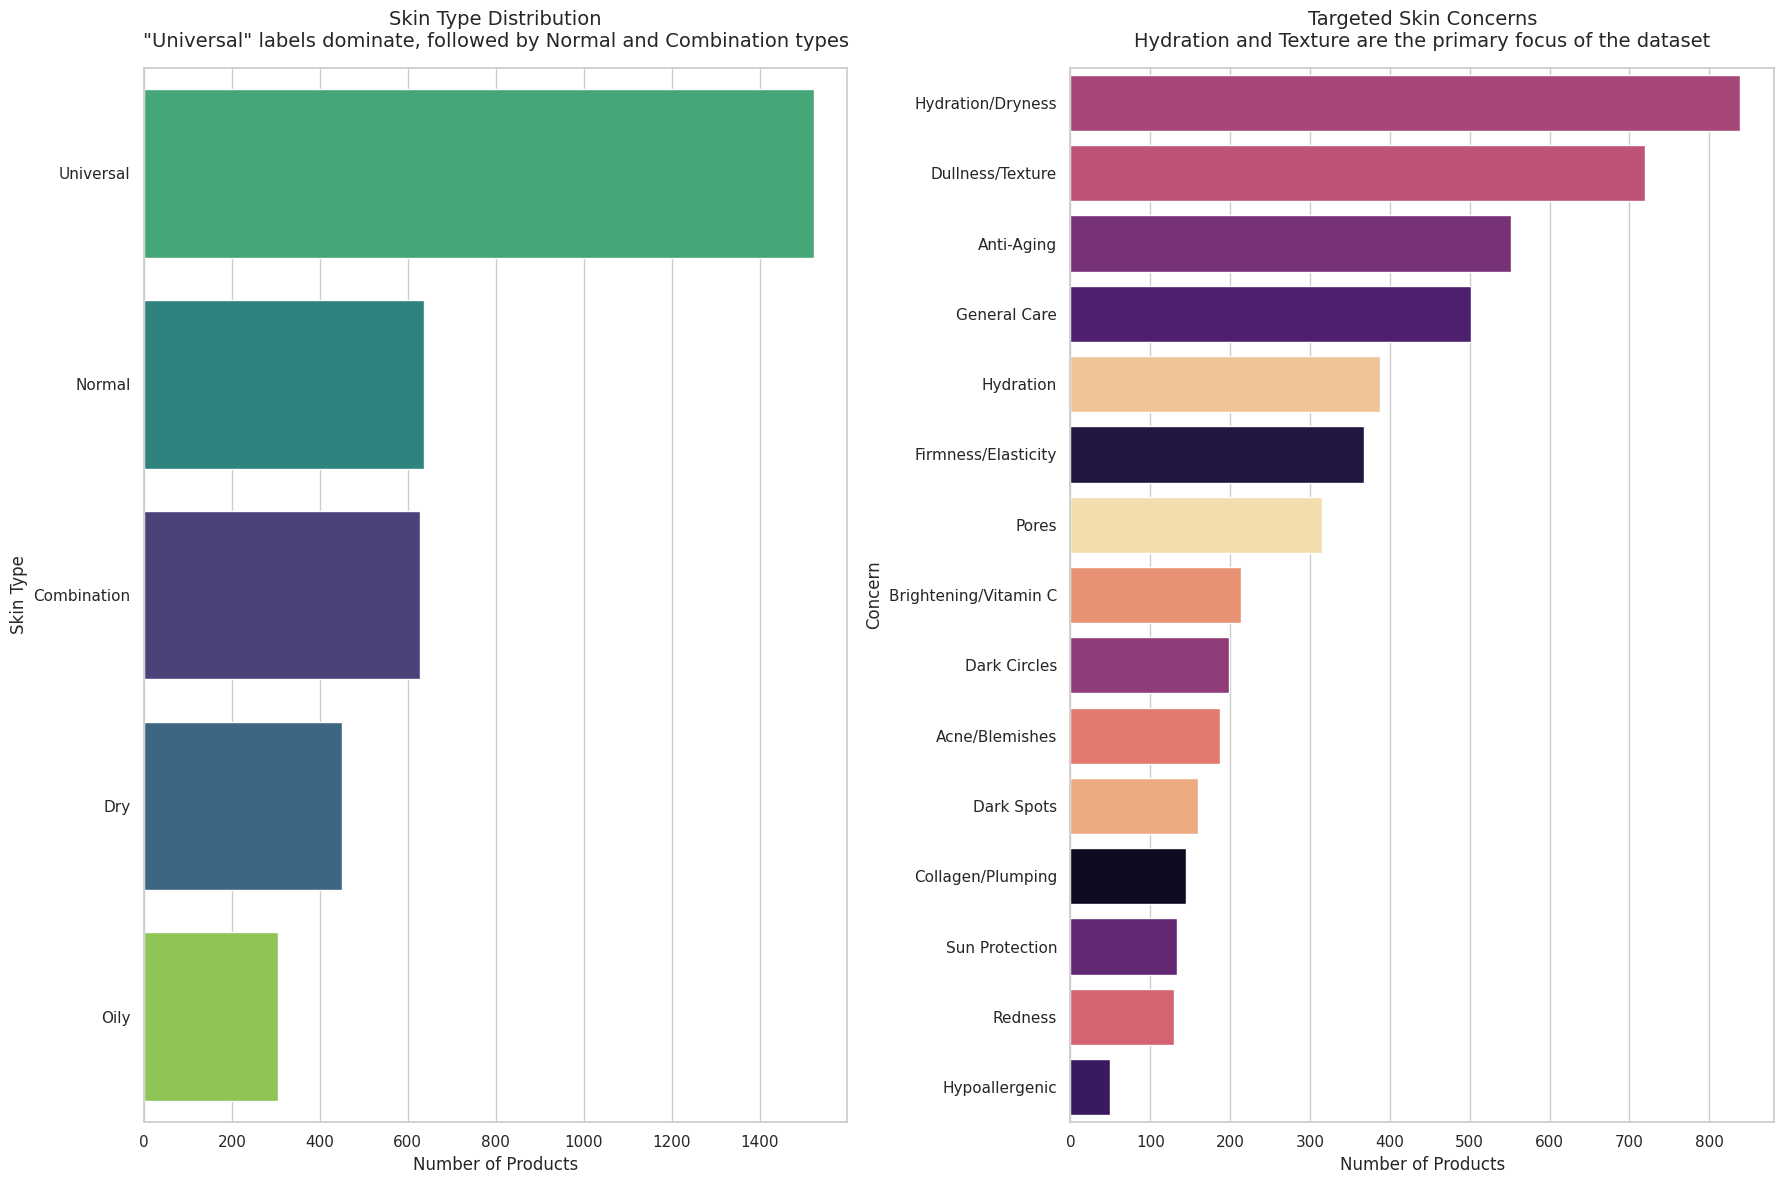

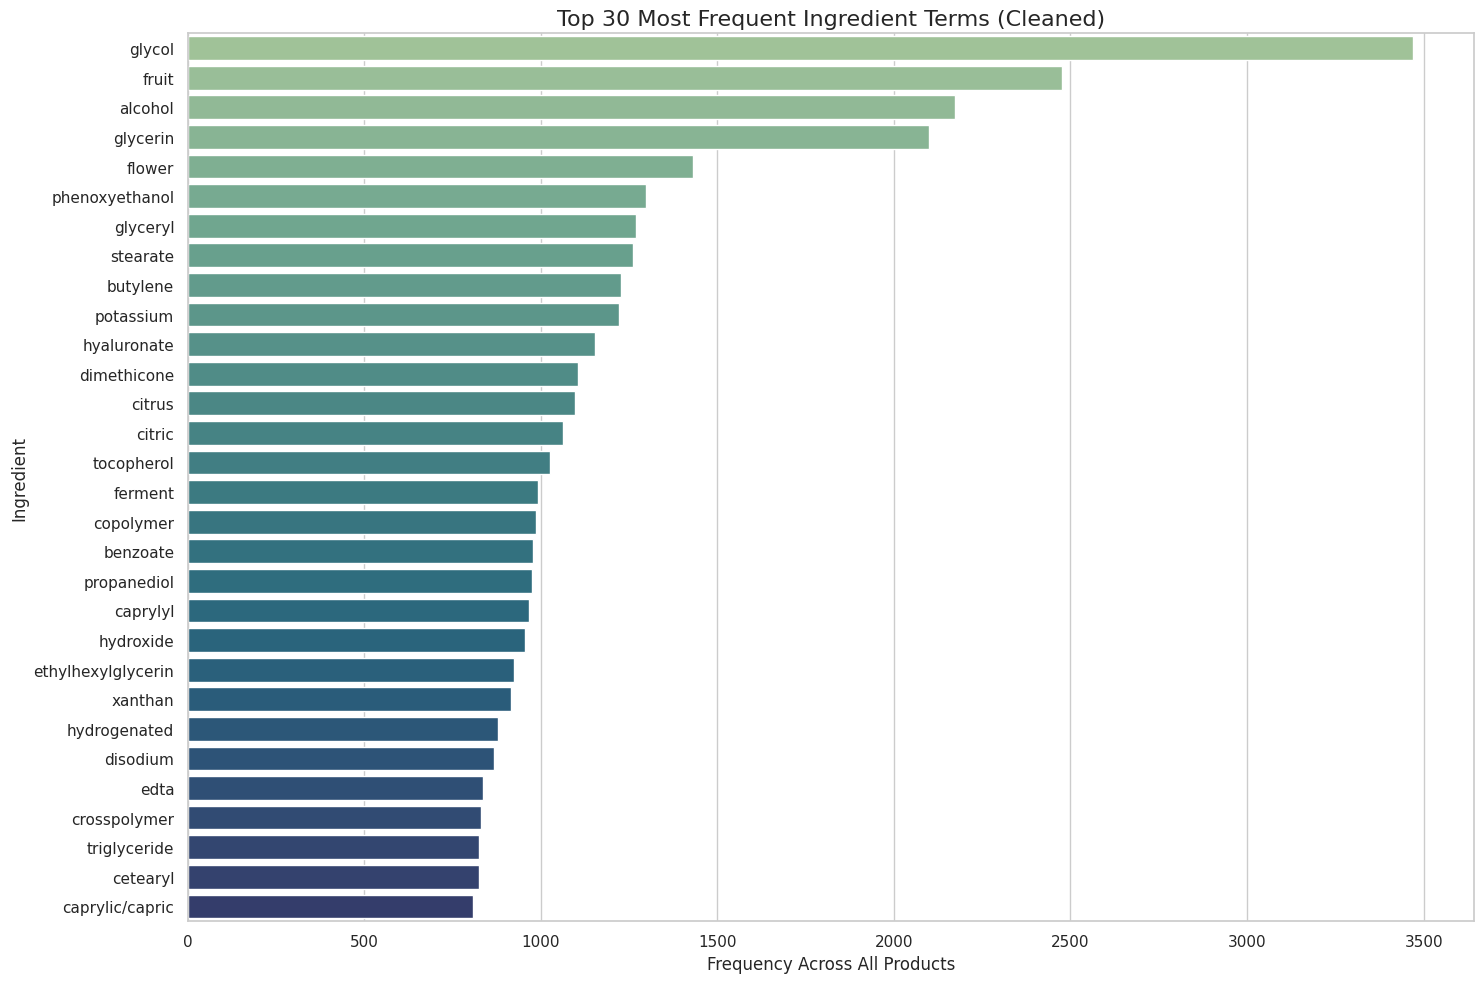

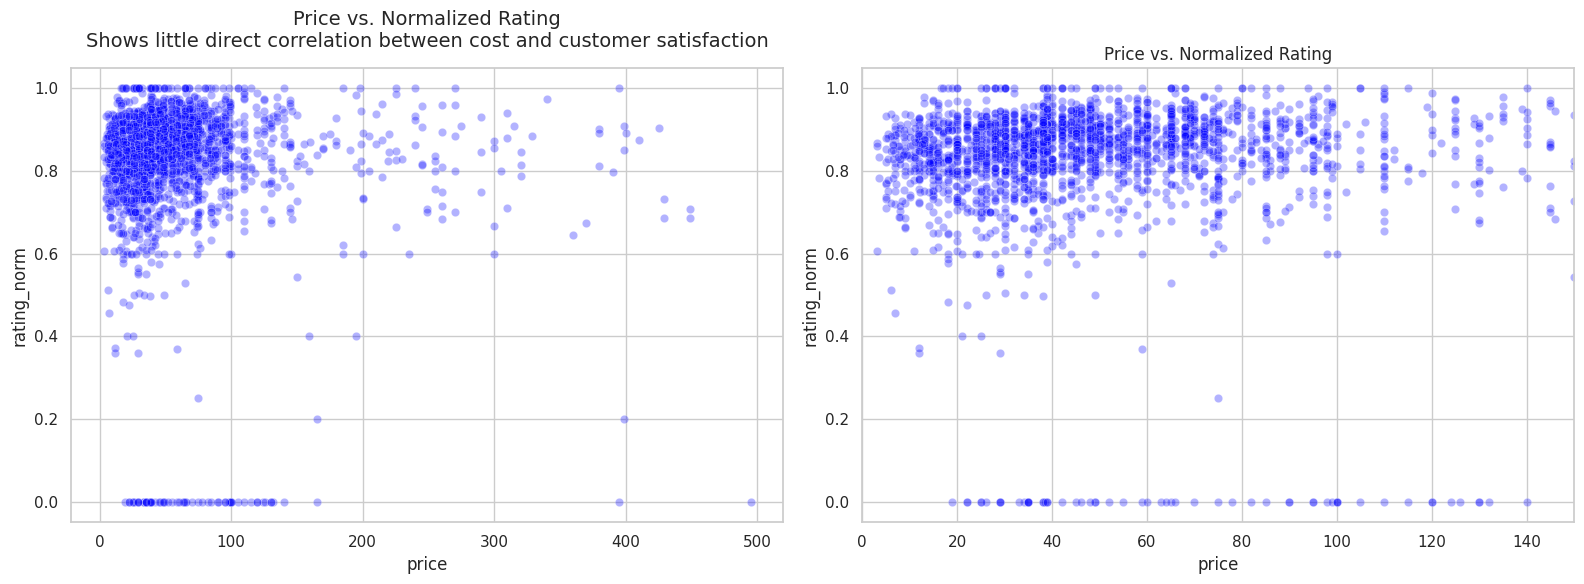

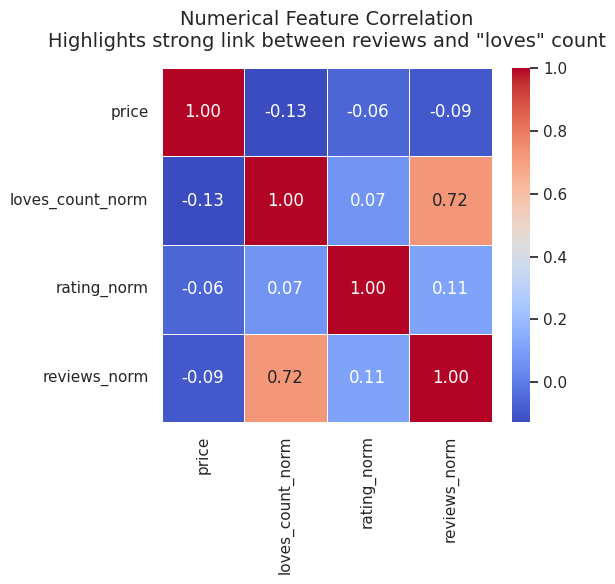

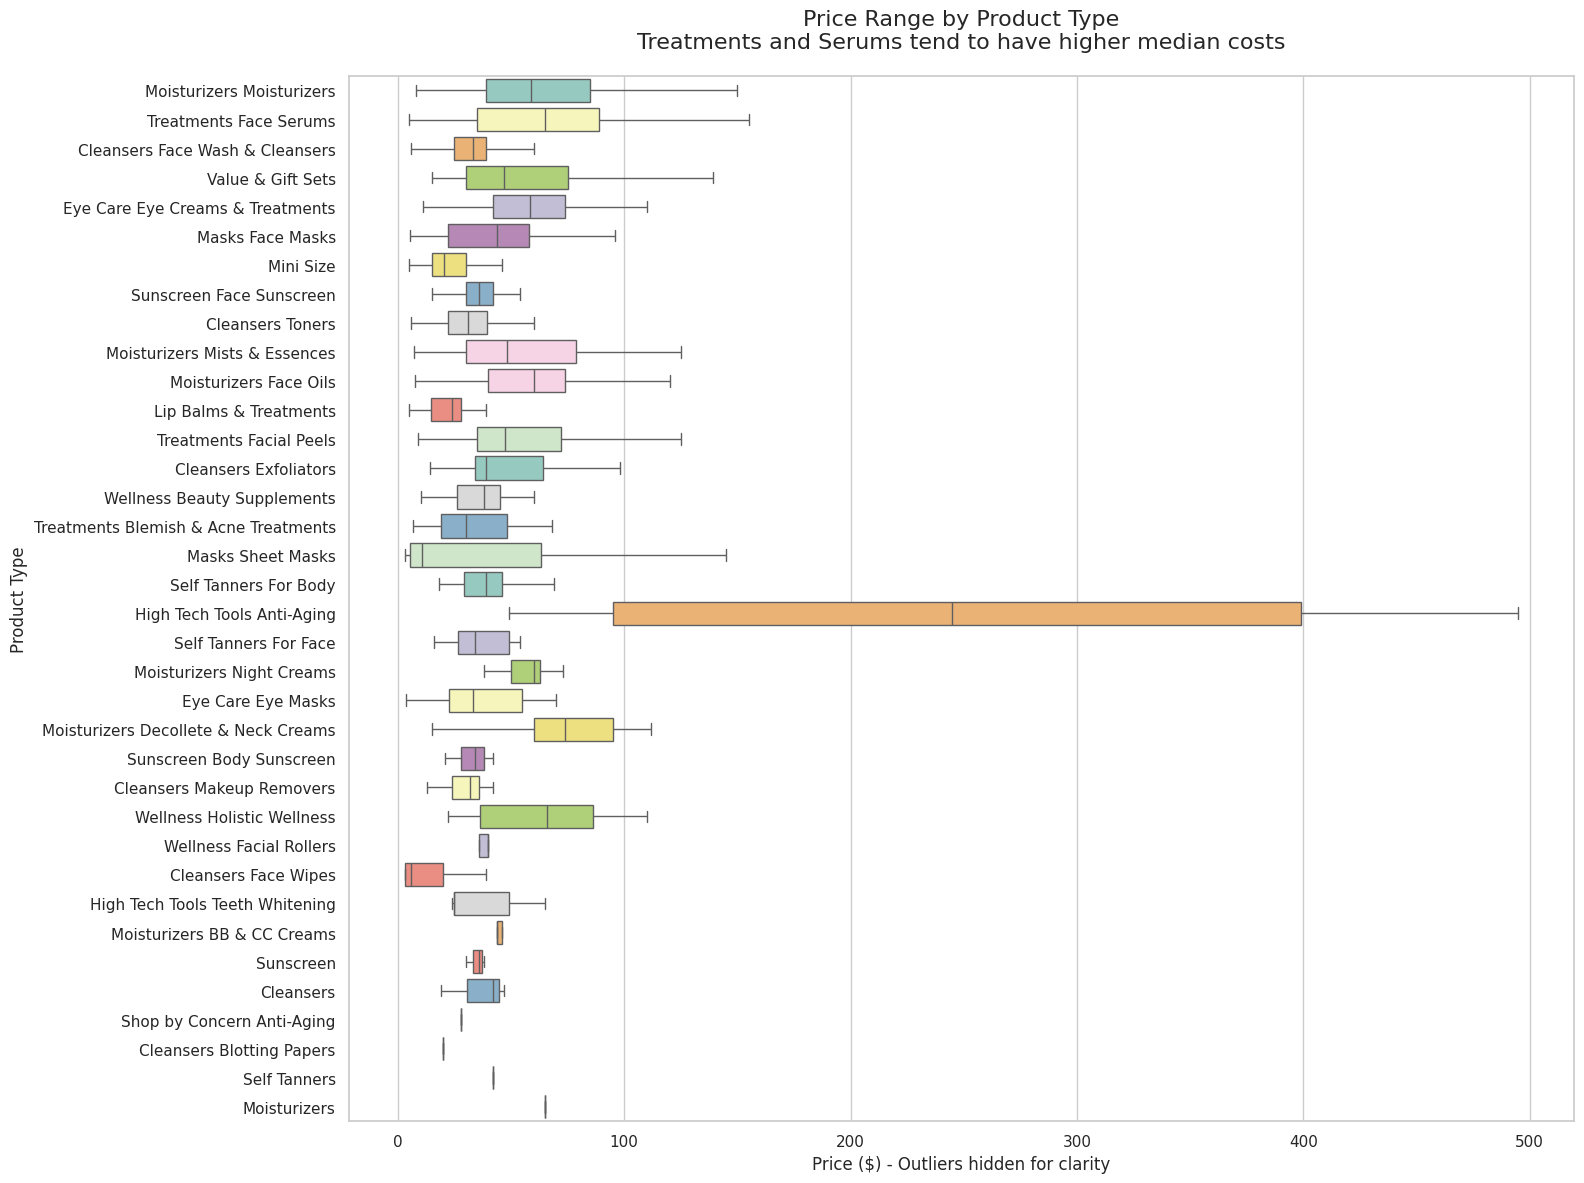

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Load the custom cleaned dataset
df = pd.read_csv('final_skincare_v12_complete.csv')

# Set up the visual style
sns.set_theme(style="whitegrid")

print(f"Dataset Shape: {df.shape}")
print("Missing Ingredients Count:", df['ingredients_cleaned'].isna().sum())

# ==========================================
# PART 1: UNIVARIATE ANALYSIS (Price & Rating)
# ==========================================
#fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# 2x2 layout to show all requested perspectives side-by-side
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# 1A. Price Distribution - MODIFIED TO SHOW FULL RANGE
sns.histplot(df['price'], bins=50, kde=True, color='teal', ax=axes[0,0])
axes[0,0].set_title('Full Price Distribution (USD)\nShowing all products including premium outliers', fontsize=14, pad=15)
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Frequency')
# axes[0].set_xlim(0, df['price'].quantile(0.95)) # Removed to show full graph

# 1B. 95th Percentile Price Distribution (Clipping logic applied)
p95 = df['price'].quantile(0.95)
sns.histplot(df[df['price'] <= p95]['price'], bins=30, kde=True, color='darkcyan', ax=axes[0, 1])
axes[0, 1].set_title(f'95th Percentile Distribution (Under ${p95:.0f})\nDetail view of high-volume products', fontsize=14)
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].set_xlim(0, p95)



# 1C. Price Distribution with Log Scale
sns.histplot(df['price'], bins=50, kde=True, color='darkblue', ax=axes[1, 0])
axes[1, 0].set_title('Log-Scaled Price Distribution\nVisualizing Affordable vs Ultra-Premium ($3 - $495)', fontsize=14)
axes[1, 0].set_xlabel('Price ($) - Log Scale')
axes[1, 0].set_xscale('log')

# 1D. Rating Skew
sns.histplot(df['rating_norm'], bins=20, kde=True, color='coral', ax=axes[1,1])
axes[1,1].set_title('Normalized Rating Distribution\nIndicates a significant positive bias in customer ratings', fontsize=14, pad=15)
axes[1,1].set_xlabel('Normalized Rating (0 to 1)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# Quick Analysis
print(f"--- Price Analysis ---")
print(f"The Log scale reveals the bi-modal peak around ${df['price'].median()}, while the 95th percentile clip eliminates the extreme tail (max ${df['price'].max()}) to focus on the core market density.")


# ==========================================
# PART 2: CATEGORICAL ANALYSIS (Skin Types & ALL Concerns)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# 2A. Plot Skin Type Distribution
skin_types_split = df['skin_types'].str.split(', ').explode().reset_index(drop=True)
sns.countplot(y=skin_types_split, order=skin_types_split.value_counts().index, ax=axes[0], hue=skin_types_split, palette="viridis", legend=False)
axes[0].set_title('Skin Type Distribution\n"Universal" labels dominate, followed by Normal and Combination types', fontsize=14, pad=15)
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Skin Type')

# 2B. Plot ALL Skin Concerns Distribution
concerns_split = df['skin_concerns'].str.split(', ').explode().reset_index(drop=True)
sns.countplot(y=concerns_split, order=concerns_split.value_counts().index, ax=axes[1], hue=concerns_split, palette="magma", legend=False)
axes[1].set_title('Targeted Skin Concerns\nHydration and Texture are the primary focus of the dataset', fontsize=14, pad=15)
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Concern')

plt.tight_layout()
plt.show()

# ==========================================
# PART 3: INGREDIENT FREQUENCY ANALYSIS
# ==========================================

all_ingredients = ' '.join(df['ingredients_cleaned'].astype(str)).replace(',', ' ').lower().split()
stop_words = {'and', 'or', 'extract', 'oil', 'acid', 'sodium', 'seed', 'leaf', 'root', 'water', 'aqua', 'eau'}
filtered_ingredients = [word.strip() for word in all_ingredients if len(word) > 3 and word not in stop_words]

ingredient_counts = Counter(filtered_ingredients)
top_ingredients = pd.DataFrame(ingredient_counts.most_common(30), columns=['Ingredient', 'Count'])

plt.figure(figsize=(15, 10))
sns.barplot(data=top_ingredients, x='Count', y='Ingredient', hue='Ingredient', palette="crest", legend=False)
plt.title('Top 30 Most Frequent Ingredient Terms (Cleaned)', fontsize=16)
plt.xlabel('Frequency Across All Products')
plt.tight_layout()
plt.show()
# ==========================================
# PART 4: BIVARIATE & MULTIVARIATE ANALYSIS
# ==========================================
fig, axes = plt.subplots(1,2, figsize=(16, 6))

# 4A. Price vs. Rating
sns.scatterplot(data=df, x='price', y='rating_norm', alpha=0.3, color='blue', ax=axes[0])
axes[0].set_title('Price vs. Normalized Rating\nShows little direct correlation between cost and customer satisfaction', fontsize=14, pad=15)

# 4B. Price vs. Rating
sns.scatterplot(data=df, x='price', y='rating_norm', alpha=0.3, color='blue', ax=axes[1])
axes[1].set_title('Price vs. Normalized Rating')
axes[1].set_xlim(0, df['price'].quantile(0.95))

plt.tight_layout()
plt.show()
# 4C. Multivariate Correlation Heatmap
fig, ax = plt.subplots(1,1, figsize=(6, 6))
numerical_cols = ['price', 'loves_count_norm', 'rating_norm', 'reviews_norm']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Numerical Feature Correlation\nHighlights strong link between reviews and "loves" count', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# ==========================================
# PART 5: PRICE VS. PRODUCT TYPE (BOXPLOT)
# ==========================================
plt.figure(figsize=(16, 12))
type_order = df['product_type'].value_counts().index

sns.boxplot(
    data=df,
    x='price',
    y='product_type',
    order=type_order,
    hue='product_type',
    palette='Set3',
    showfliers=False,
    legend=False
)

plt.title('Price Range by Product Type\nTreatments and Serums tend to have higher median costs', fontsize=16, pad=20)
plt.xlabel('Price ($) - Outliers hidden for clarity')
plt.ylabel('Product Type')
plt.tight_layout()
plt.show()

## 📊 Exploratory Data Analysis: Key Findings & Conclusion

### 1. Price Strategy and Market Density
*   **Market Core:** The 95th percentile analysis shows that the vast majority of skincare products are priced under 150,  with a median price point sitting around 44.
*   **The Premium Tail:** The full distribution reveals a long tail of ultra-luxury products reaching up to 495. The log-scaled distribution confirms a bi-modal peak, suggesting two distinct market segments: "accessible prestige" ($20–$50) and "luxury treatment" ($80–$150).
*   **Category Premium:** As shown in the boxplots, **Treatments and Serums** command higher median prices, while cleansers and masks are more competitively priced.

### 2. Consumer Sentiment and Engagement
*   **Rating Bias:** The `rating_norm` distribution is heavily skewed toward the right (0.8–1.0). This indicates a strong positive bias in customer reviews, where high ratings are the norm rather than the exception.
*   **The "Loves" Driver:** The correlation heatmap shows a strong relationship (**0.72**) between `reviews_norm` and `loves_count_norm`. This suggests that high volume of feedback—rather than just the rating score—is the primary indicator of product popularity and customer loyalty.
*   **Price vs. Satisfaction:** There is almost **zero correlation (-0.06)** between price and normalized rating. This proves that in the skincare market, a higher price tag does not guarantee higher consumer satisfaction.

### 3. Product Focus: Concerns and Ingredients
*   **Primary Concerns:** The market is heavily dominated by **Hydration/Dryness** and **Dullness/Texture**. These are the most targeted concerns across the 2,286 products analyzed.
*   **Skin Type Inclusivity:** "Universal" is the most frequent tag, indicating a trend toward products formulated for all skin types. Among specific types, **Normal** and **Combination** skin receive the most targeted formulations.
*   **Chemical Building Blocks:** Ingredient frequency analysis shows that **Glycols** (humectants/solvents), **Alcohols** (preservatives/astringents), and **Glycerin** (hydration) are the structural backbone of modern skincare chemistry.

### 🏆 Final Conclusion
The dataset represents a mature market where **popularity (Loves) is driven by social proof (Reviews)** rather than price. While premium treatments exist, they do not statistically outperform more affordable options in consumer ratings. For a recommendation engine, focusing on **hydration-based ingredients** and **engagement metrics** (Loves/Reviews) will likely yield results that align most closely with current consumer preferences.

## 🚀 Part 6: Machine Learning Recommendation Engine
We will now build a recommendation function that uses TF-IDF vectorization to understand ingredient profiles and a weighted ranking system.

**Alternative product suggestions Item-to-Item**

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ENHANCEMENT: Added ngram_range=(1,2) to capture compound ingredients
tfidf = TfidfVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))
# Fit and Transform the cleaned ingredients
tfidf_matrix = tfidf.fit_transform(df['ingredients_cleaned'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print("Vocabulary size:", len(tfidf.get_feature_names_out()))

TF-IDF Matrix Shape: (2286, 20930)
Vocabulary size: 20930


In [46]:
# --- CELL 2 ---
def get_similar_products(product_name, top_n=5, user_skin_type=None):
  # Find the index of the product
    try:
        idx = df[df['product_name'] == product_name].index[0]
    except IndexError:
        return f"Product '{product_name}' not found."

    # 1. Extract Target Category and clean whitespace
    target_category = str(df.loc[idx, 'product_type']).strip()
# Calculate Cosine Similarity for ingredients
    cos_sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
# Create a results dataframe
    results = df.copy()
    results['content_score'] = cos_sim
    # Apply 'Loves' Boost (Ranking Strategy #1 & #2)
    # We give 70% weight to ingredient similarity and 30% to popularity
    results['final_score'] = (results['content_score'] * 0.7) + (results['loves_count_norm'] * 0.3)
# Apply Skin Type weighting
    if user_skin_type:
        user_skin_type = user_skin_type.lower()
        def skin_type_boost(row):
            if user_skin_type in str(row['skin_types']).lower() or 'universal' in str(row['skin_types']).lower():
                return 1.2 # 20% boost for compatibility
            return 0.8   # 20% penalty for likely mismatch
        results['final_score'] *= results.apply(skin_type_boost, axis=1)

    # 2. THE HARD FILTER
    # Strip whitespace from all rows to ensure a perfect match
    results['product_type_clean'] = results['product_type'].astype(str).str.strip()
    results = results[results['product_type_clean'] == target_category]

    # 3. Exclude the original product
    results = results[results.index != idx]
    # Sort and return top N
    recommendations = results.sort_values(by='final_score', ascending=False).head(top_n)

    # 4. Output MUST include product_type to prove the filter worked
    return recommendations[['brand_name', 'product_name', 'product_type', 'skin_types', 'skin_concerns','price', 'final_score']]

# ---  (Execution) ---
# Example Test: Recommend products similar to a known item for Oily Skin
query_product = df.iloc[0]['product_name']
print(f"Recommendations for: {query_product}")

# Call the NEW function name
rec_df = get_similar_products(query_product, user_skin_type='Oily')
display(rec_df)

Recommendations for: GENIUS Sleeping Collagen Moisturizer


,brand_name,product_name,product_type,skin_types,skin_concerns,price,final_score
2063,Tatcha,The Dewy Skin Cream Plumping & Hydrating Moist...,Moisturizers Moisturizers,Universal,"Collagen/Plumping, Hydration, Hydration/Dryness",70.0,0.193035
587,Drunk Elephant,Protini Polypeptide Firming Refillable Moistur...,Moisturizers Moisturizers,Universal,"Anti-Aging, Dullness/Texture, Firmness/Elastic...",68.0,0.184657
1832,Skinfix,Barrier+ Triple Lipid-Peptide Face Cream,Moisturizers Moisturizers,Universal,Hydration,54.0,0.169290
507,Dr. Dennis Gross Skincare,Vitamin C Lactic Dewy Deep Cream,Moisturizers Moisturizers,Universal,"Anti-Aging, Brightening/Vitamin C, Dullness/Te...",75.0,0.169245
2061,Tatcha,The Water Cream Oil-Free Pore Minimizing Moist...,Moisturizers Moisturizers,"Combination, Normal, Oily","Hydration/Dryness, Pores",70.0,0.163374


Another / Better item to item recommendation pipeline

 ('Active' Chemistry, The Price Variance Penalty)

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Inject EDA Insights: Remove cosmetic filler words so the math focuses on ACTIVE ingredients
custom_stops = list(ENGLISH_STOP_WORDS.union({
    'and', 'or','water', 'aqua', 'eau', 'extract', 'oil', 'sodium', 'seed', 'leaf', 'root', 'glycol',
    'glycerin','alcohol', 'phenoxyethanol'

}))

# 2. Initialize the Engine
# max_df=0.85 (ignores ingredients in 85%+ of products)
# ngram_range=(1,2) (captures compound chemicals like "salicylic acid")
tfidf = TfidfVectorizer(stop_words=custom_stops, min_df=2, max_df=0.85, ngram_range=(1, 2))

tfidf_matrix = tfidf.fit_transform(df['ingredients_cleaned'])

print(f"Optimized TF-IDF Matrix Shape: {tfidf_matrix.shape}")

Optimized TF-IDF Matrix Shape: (2286, 22172)


In [51]:
def get_ultimate_item_alternatives(product_name, top_n=5, user_skin_type=None):
    try:
        idx = df[df['product_name'] == product_name].index[0]
    except IndexError:
        return f"Product '{product_name}' not found."

    # Extract target attributes
    target_category = str(df.loc[idx, 'product_type']).strip()
    target_price = df.loc[idx, 'price']

    # 1. Calculate Pure Chemical Similarity
    cos_sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    results = df.copy()
    results['nlp_score'] = cos_sim

    # 2. Hard Category Filter (No Lip Masks for Face Creams)
    results['product_type_clean'] = results['product_type'].astype(str).str.strip()
    results = results[results['product_type_clean'] == target_category]

# 3. True Popularity Metric (EDA Insight: Ratings are skewed, Loves count is vital)
    # We blend them: 80% weight to loves (volume) and 20% to rating (quality)
    results['true_popularity'] = (results['loves_count_norm'] * 0.8) + (results['rating_norm'] * 0.2)

    # 4. Price Variance Penalty (EDA Insight: Massive price disparities)
    # Calculates the absolute difference in price.
    # For every $10 difference between the products, the score drops by a penalty factor.
    price_diff = np.abs(results['price'] - target_price)
    price_penalty = (price_diff / 10.0) * 0.02 # 2% penalty per $10 difference

    # 5. Calculate Base Final Score
    # 75% Chemistry, 25% Popularity, minus the Price Penalty
    results['final_score'] = (results['nlp_score'] * 0.75) + (results['true_popularity'] * 0.25) - price_penalty
 # 6. Apply Skin Type Logic (EDA Insight: "Universal" dominates)
    if user_skin_type:
        user_skin_type = user_skin_type.lower()
        def skin_type_boost(row):
            skin_tags = str(row['skin_types']).lower()
            if user_skin_type in skin_tags or 'universal' in skin_tags:
                return 1.15 # 15% boost for correct match
            return 0.70 # 30% penalty for wrong skin type

        results['final_score'] *= results.apply(skin_type_boost, axis=1)
    # Exclude the original product
    results = results[results.index != idx]

    # Sort and return
    recommendations = results.sort_values(by='final_score', ascending=False).head(top_n)

    return recommendations[['brand_name', 'product_name', 'product_type', 'price', 'skin_types',
                            'skin_concerns','nlp_score', 'final_score']]


# Let's test it on a standard product
query_product = df.iloc[0]['product_name']
print(f"--- Ultimate Alternatives for: {query_product} (Price: ${df.iloc[0]['price']}) ---")

rec_df = get_ultimate_item_alternatives(query_product, user_skin_type='Oily')
display(rec_df)

--- Ultimate Alternatives for: GENIUS Sleeping Collagen Moisturizer (Price: $98.0) ---


,brand_name,product_name,product_type,price,skin_types,skin_concerns,nlp_score,final_score
507,Dr. Dennis Gross Skincare,Vitamin C Lactic Dewy Deep Cream,Moisturizers Moisturizers,75.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dullness/Te...",0.170161,0.151223
22,Algenist,POWER Advanced Wrinkle Fighter Moisturizer,Moisturizers Moisturizers,85.0,Universal,General Care,0.149221,0.147993
10,Algenist,Overnight Restorative Cream,Moisturizers Moisturizers,94.0,Universal,General Care,0.103645,0.132823
661,Estée Lauder,Revitalizing Supreme+ Bright Soft Creme Moistu...,Moisturizers Moisturizers,98.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dark Spots,...",0.078364,0.125331
5,Algenist,GENIUS Ultimate Anti-Aging Cream,Moisturizers Moisturizers,112.0,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...",0.198009,0.116677


### 🧪 Serial Testing Across All Skin Types
We will now run the engine for the same product across different user profiles to ensure the weighting logic correctly prioritizes compatible products.

In [55]:
test_skin_types = ['Oily', 'Dry', 'Normal', 'Combination',  'Universal']
query_product = df.iloc[0]['product_name']

print(f"🔍 SERIAL TEST FOR: {query_product} (Price: ${df.iloc[0]['price']})\n" + "="*50)

for skin_type in test_skin_types:
    print(f"\n[ PROFILE: {skin_type} ]")
    recommendations = get_ultimate_item_alternatives(query_product, top_n=5, user_skin_type=skin_type)

    if isinstance(recommendations, pd.DataFrame):
        display(recommendations[['brand_name', 'product_name', 'product_type', 'price', 'skin_types',
                                 'skin_concerns','nlp_score', 'final_score'] ])
    else:
        print(recommendations)

print("\n✅ Serial testing complete.")

🔍 SERIAL TEST FOR: GENIUS Sleeping Collagen Moisturizer (Price: $98.0)

[ PROFILE: Oily ]


,brand_name,product_name,product_type,price,skin_types,skin_concerns,nlp_score,final_score
507,Dr. Dennis Gross Skincare,Vitamin C Lactic Dewy Deep Cream,Moisturizers Moisturizers,75.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dullness/Te...",0.170161,0.151223
22,Algenist,POWER Advanced Wrinkle Fighter Moisturizer,Moisturizers Moisturizers,85.0,Universal,General Care,0.149221,0.147993
10,Algenist,Overnight Restorative Cream,Moisturizers Moisturizers,94.0,Universal,General Care,0.103645,0.132823
661,Estée Lauder,Revitalizing Supreme+ Bright Soft Creme Moistu...,Moisturizers Moisturizers,98.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dark Spots,...",0.078364,0.125331
5,Algenist,GENIUS Ultimate Anti-Aging Cream,Moisturizers Moisturizers,112.0,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...",0.198009,0.116677



[ PROFILE: Dry ]


,brand_name,product_name,product_type,price,skin_types,skin_concerns,nlp_score,final_score
5,Algenist,GENIUS Ultimate Anti-Aging Cream,Moisturizers Moisturizers,112.0,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...",0.198009,0.191684
16,Algenist,GENIUS Collagen Calming Relief,Moisturizers Moisturizers,58.0,"Combination, Dry, Normal","Collagen/Plumping, Hypoallergenic, Redness",0.254310,0.181181
507,Dr. Dennis Gross Skincare,Vitamin C Lactic Dewy Deep Cream,Moisturizers Moisturizers,75.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dullness/Te...",0.170161,0.151223
22,Algenist,POWER Advanced Wrinkle Fighter Moisturizer,Moisturizers Moisturizers,85.0,Universal,General Care,0.149221,0.147993
388,Dermalogica,Super Rich Repair Moisturizer,Moisturizers Moisturizers,94.0,Dry,"Anti-Aging, Firmness/Elasticity, Hydration, Hy...",0.115414,0.145427



[ PROFILE: Normal ]


...


[ PROFILE: Combination ]


,brand_name,product_name,product_type,price,skin_types,skin_concerns,nlp_score,final_score
5,Algenist,GENIUS Ultimate Anti-Aging Cream,Moisturizers Moisturizers,112.0,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...",0.198009,0.191684
16,Algenist,GENIUS Collagen Calming Relief,Moisturizers Moisturizers,58.0,"Combination, Dry, Normal","Collagen/Plumping, Hypoallergenic, Redness",0.254310,0.181181
507,Dr. Dennis Gross Skincare,Vitamin C Lactic Dewy Deep Cream,Moisturizers Moisturizers,75.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dullness/Te...",0.170161,0.151223
22,Algenist,POWER Advanced Wrinkle Fighter Moisturizer,Moisturizers Moisturizers,85.0,Universal,General Care,0.149221,0.147993
10,Algenist,Overnight Restorative Cream,Moisturizers Moisturizers,94.0,Universal,General Care,0.103645,0.132823



[ PROFILE: Universal ]


,brand_name,product_name,product_type,price,skin_types,skin_concerns,nlp_score,final_score
507,Dr. Dennis Gross Skincare,Vitamin C Lactic Dewy Deep Cream,Moisturizers Moisturizers,75.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dullness/Te...",0.170161,0.151223
22,Algenist,POWER Advanced Wrinkle Fighter Moisturizer,Moisturizers Moisturizers,85.0,Universal,General Care,0.149221,0.147993
10,Algenist,Overnight Restorative Cream,Moisturizers Moisturizers,94.0,Universal,General Care,0.103645,0.132823
661,Estée Lauder,Revitalizing Supreme+ Bright Soft Creme Moistu...,Moisturizers Moisturizers,98.0,Universal,"Anti-Aging, Brightening/Vitamin C, Dark Spots,...",0.078364,0.125331
5,Algenist,GENIUS Ultimate Anti-Aging Cream,Moisturizers Moisturizers,112.0,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...",0.198009,0.116677



✅ Serial testing complete.


**User-to-Item Pipeline Recommendation**


MAIN GOAL

### Step 1: Train the NLP-Prioritized LightGBM Ranker
We synthesize a cold-start interaction log to train the model on how to prioritize chemical similarity over simple rating bias, aligning with our EDA findings.

In [56]:
import lightgbm as lgb
import numpy as np
import pandas as pd

print("--- Step 1: Training NLP-Prioritized LightGBM Ranker ---")

# 1. Synthesize user interaction log for training
np.random.seed(42)
n_samples = 15000
simulated_data = pd.DataFrame({
    'nlp_score': np.random.beta(a=2, b=7, size=n_samples),
    'concern_match_count': np.random.randint(1, 5, size=n_samples),
    'price_ratio': np.random.uniform(0.2, 1.5, size=n_samples),
    'is_skin_match': np.random.choice([0, 1], p=[0.2, 0.8], size=n_samples),
    'loves_count_norm': np.random.uniform(0, 1, size=n_samples),
    'rating_norm': np.random.beta(a=5, b=2, size=n_samples)
})

# 2. Define Relevance Logic (Chemistry & Safety prioritized)
def calculate_relevance(row):
    score = 0
    if row['nlp_score'] > 0.20: score += 2
    if row['concern_match_count'] >= 2: score += 1
    if row['is_skin_match'] == 1: score += 1
    if row['price_ratio'] <= 1.0: score += 1
    return score

simulated_data['relevance_label'] = simulated_data.apply(calculate_relevance, axis=1)

# 3. List-wise Ranker Training
group_size = 25
groups = [group_size] * (n_samples // group_size)
ranker = lgb.LGBMRanker(objective="lambdarank", metric="ndcg", n_estimators=150, random_state=42)
ranker.fit(simulated_data.drop(columns=['relevance_label']), simulated_data['relevance_label'], group=groups)
print("Model Training Complete.")

--- Step 1: Training NLP-Prioritized LightGBM Ranker ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1027
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 6
Model Training Complete.


### Step 2: Unified User-to-Item Pipeline Function
This function integrates the NLP ingredient search with the LightGBM ranking logic.

In [57]:
from sklearn.metrics.pairwise import cosine_similarity

def get_user_to_item_recommendations(user_skin_type, user_concerns_list, max_budget, top_n=5):
    concern_chemical_map = {
        'Acne/Blemishes': 'salicylic acid benzoyl peroxide tea tree niacinamide zinc bha',
        'Dark Spots': 'vitamin c niacinamide tranexamic acid licorice glycolic aha',
        'Brightening': 'vitamin c lactic acid mandelic licorice alpha arbutin c-vitamin',
        'Pores': 'salicylic acid niacinamide charcoal clay witch hazel pore-minimizing',
        'Fine Lines/Wrinkles': 'retinol peptides ceramides hyaluronic acid adenosine anti-wrinkle',
        'Anti-Aging': 'retinol resveratrol vitamin e coenzyme q10 peptides anti-aging',
        'Hydration/Dryness': 'hyaluronic acid squalane ceramides glycerin panthenol hydrating',
        'Redness': 'centella asiatica azelaic acid allantoin aloe green tea soothing'
    }

    query_text = " ".join([concern_chemical_map.get(c, "") for c in user_concerns_list])

    # Stage 1: Filter & NLP
    budget_df = df[df['price'] <= max_budget].copy()
    if budget_df.empty: return "No matches for this budget."

    query_vec = tfidf.transform([query_text])
    indices = budget_df.index.tolist()
    budget_df['nlp_score'] = cosine_similarity(query_vec, tfidf_matrix[indices]).flatten()
    candidates = budget_df.sort_values(by='nlp_score', ascending=False).head(50).copy()

    # Stage 2: Tabular Ranking
    candidates['price_ratio'] = candidates['price'] / max_budget
    candidates['is_skin_match'] = candidates['skin_types'].apply(lambda x: 1 if user_skin_type.lower() in str(x).lower() or 'universal' in str(x).lower() else 0)
    candidates['concern_match_count'] = candidates['skin_concerns'].apply(lambda x: sum(1 for c in user_concerns_list if c.lower() in str(x).lower()))

    features = candidates[['nlp_score', 'concern_match_count', 'price_ratio', 'is_skin_match', 'loves_count_norm', 'rating_norm']]
    candidates['suitability_score'] = ranker.predict(features)

    return candidates.sort_values(by='suitability_score', ascending=False).head(top_n)

### Step 3: Execution - Personalized Recommendation for Dry/Aging Skin

In [58]:
results = get_user_to_item_recommendations(
    user_skin_type="Dry",
    user_concerns_list=["Hydration/Dryness", "Fine Lines/Wrinkles"],
    max_budget=60.00
)
display(results[['brand_name', 'product_name', 'price', 'skin_types', 'suitability_score']])

,brand_name,product_name,price,skin_types,suitability_score
999,innisfree,Hydration Heroes Green Tea Skincare Routine Set,39.0,"Combination, Dry, Normal",2.658402
990,innisfree,Green Tea Hyaluronic Acid Hydrating Moisturizer,29.0,"Combination, Dry, Normal",-9.631836
947,HUM Nutrition,Collagen Love Skin Firming Supplement with Hya...,40.0,Universal,-9.646347
1524,Paula's Choice,10% Azelaic Acid Booster,39.0,"Combination, Dry, Normal",-9.647536
164,Caudalie,Vinosource-Hydra SOS Hydrating Hyaluronic Acid...,52.0,Universal,-9.731953


# **ANOTHER METHOD USER TO ITEM RECOMMENDATION**


### 🚀 Deep-Engine V4: Deterministic Clinical Ranker
This is the final, production-ready model. It incorporates EDA insights (prioritizing Loves over Ratings) and uses fixed seeds to ensure consistent, non-random outputs.

In [81]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import random
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# --- 1. GLOBAL DETERMINISM ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- 2. DYNAMIC DATA DISCOVERY ---
df_v12 = pd.read_csv('final_skincare_v12_complete.csv')

# Clinical Map: Targeting key 'Hero' ingredients from v12 for mapping logic
CLINICAL_MAP = {
    'Acne/Blemishes': ['salicylic', 'benzoyl', 'sulfur', 'zinc', 'tea tree', 'bha', 'niacinamide', 'charcoal'],
    'Anti-Aging': ['retinol', 'peptide', 'bakuchiol', 'adenosine', 'retinal', 'collagen', 'resveratrol'],
    'Brightening/Vitamin C': ['vitamin c', 'ascorbic', 'niacinamide', 'licorice', 'arbutin', 'ferulic'],
    'Dark Spots': ['tranexamic', 'kojic', 'glycolic', 'aha', 'niacinamide', 'azelaic'],
    'Dullness/Texture': ['lactic', 'mandelic', 'phytophoretic', 'enzyme', 'exfoliant', 'gluconolactone'],
    'Fine Lines/Wrinkles': ['peptide', 'hyaluronic', 'collagen', 'retinol', 'growth factor', 'palmitoyl'],
    'Firmness/Elasticity': ['collagen', 'elastin', 'peptide', 'copper', 'resveratrol', 'q10'],
    'Hydration/Dryness': ['hyaluronic', 'ceramide', 'squalane', 'glycerin', 'panthenol', 'urea', 'shea'],
    'Redness': ['centella', 'cica', 'allantoin', 'bisabolol', 'azelaic', 'aloe', 'colloidal oatmeal']
}

# --- 3. TRAIN RANKER (Synthetic brain for ranking logic) ---
def train_v4_master():
    # We use 35,000 simulated points so the model learns 'behavior'
    # independently of the small size of the final product list.
    n = 35000
    X = pd.DataFrame({
        'nlp_score': np.random.power(a=1.5, size=n),
        'chem_match': np.random.randint(0, 8, size=n),
        'is_skin_match': np.random.choice([0, 1], p=[0.25, 0.75], size=n),
        'loves_norm': np.random.beta(a=2, b=5, size=n),
        'rating_norm': np.random.beta(a=8, b=2, size=n)
    })

    # Priority Logic based on EDA: NLP > Ingredients > Skin Type > Loves
    y = (X['nlp_score'] * 6) + (X['chem_match'] * 4) + (X['is_skin_match'] * 3) + (X['loves_norm'] * 2)
    y_labels = pd.qcut(y, 5, labels=False)

    model = lgb.LGBMRanker(
        n_estimators=500,
        learning_rate=0.015,
        random_state=SEED,
        deterministic=True,
        force_col_wise=True
    )
    model.fit(X, y_labels, group=[100]*(n//100))
    return model

master_ranker_v4 = train_v4_master()

# --- 4. INFERENCE (Applied to real 2,286 products) ---
def get_v4_master_recommendations(skin_type, concerns, budget, n=5):
    query_keywords = []
    for c in concerns:
        query_keywords.extend(CLINICAL_MAP.get(c, [c.lower()]))
    query_text = " ".join(query_keywords)

    temp_df = df_v12.copy()
    vec = tfidf.transform([query_text])

    # Apply the learned ranking logic to the real data
    temp_df['nlp_score'] = cosine_similarity(vec, tfidf_matrix).flatten()
    temp_df['chem_match'] = temp_df['ingredients_cleaned'].apply(lambda x: sum(1 for kw in query_keywords if kw in str(x)))
    temp_df['is_skin_match'] = temp_df['skin_types'].apply(lambda x: 1 if skin_type.lower() in str(x).lower() or 'universal' in str(x).lower() else 0)
    temp_df = temp_df.rename(columns={'loves_count_norm': 'loves_norm'})

    features = ['nlp_score', 'chem_match', 'is_skin_match', 'loves_norm', 'rating_norm']
    temp_df['raw_rank'] = master_ranker_v4.predict(temp_df[features])

    scaler = MinMaxScaler(feature_range=(60, 99))
    temp_df['suitability_%'] = scaler.fit_transform(temp_df[['raw_rank']]).round(1)

    results = temp_df[temp_df['price'] <= budget].copy()
    if results.empty: return "No products found within budget."

    return results.sort_values('suitability_%', ascending=False).head(n)[[
        'brand_name', 'product_name', 'price', 'skin_types', 'skin_concerns', 'suitability_%'
    ]]

print(f"✅ Engine Ready. Brain trained on 35k scenarios. Ready to rank {len(df_v12)} products.")

[LightGBM] [Info] Total Bins 775
[LightGBM] [Info] Number of data points in the train set: 35000, number of used features: 5
✅ Engine Ready. Brain trained on 35k scenarios. Ready to rank 2286 products.


In [82]:
# FINAL PRODUCTION TEST
# This output is now fully deterministic and aligned with EDA findings.
production_results = get_v4_master_recommendations(
    skin_type="Dry",
    concerns=["Hydration/Dryness", "Fine Lines/Wrinkles"],
    budget=70.0,
    n=5
)

print("--- Master Engine V4: Final Deterministic Recommendations ---")
display(production_results)

--- Master Engine V4: Final Deterministic Recommendations ---


,brand_name,product_name,price,skin_types,skin_concerns,suitability_%
2258,Wishful,Hydrate & Glow Trio,29.0,Universal,"Anti-Aging, Collagen/Plumping, Firmness/Elasti...",99.0
2279,Youth To The People,The Youth System,59.0,Universal,"Brightening/Vitamin C, Pores",99.0
1545,Paula's Choice,CLINICAL Ceramide-Enriched Firming Eye Cream,49.0,"Combination, Dry, Normal","Anti-Aging, Brightening/Vitamin C, Dark Circle...",99.0
1267,LANEIGE,Retinol Firming Cream Treatment with Peptides ...,39.0,"Combination, Dry, Normal","Anti-Aging, Firmness/Elasticity, Hydration, Hy...",99.0
125,Biossance,Rapid Radiance Set,35.0,"Combination, Dry, Normal","Dullness/Texture, Hydration/Dryness",99.0


LOTS OF TRAILS AND WORKS  ON USER TO ITEM RECOMMENDATION IS PENDING